<img src="https://s3-us-west-2.amazonaws.com/public.notion-static.com/7fa59d58-ba42-4de1-840a-e2e31ab9ce3b/ba416d9e-ee4d-4b7a-a9fe-a506333af2b7.png" alt="Abstract Banner" width="100%" height="200" style="object-fit: cover; border-radius: 8px;">
by: Elmar Leonard, Muhammad Rafi Andrianto and Valencia

# **Section 0: Project Initialization**

## **0.1 Importing Library**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
DATA_DIR = 'Dataset' 

df = pd.read_csv(f'../{DATA_DIR}/Merged Data/merged.csv')

# **Section 1: Business Explanation**

## **1.1 Business Context**

**Olist** is the largest department store in Brazilian marketplaces. Olist connects small businesses from all over Brazil to channels without hassle and with a single contract. Those merchants are able to sell their products through the Olist Store and ship them directly to the customers using Olist logistics partners.  
  
So **Olist** acts as a bridge between shoppers and sellers. When a customer buys something from the Olist Store, the seller is notified to ship the item. After delivery (or once the estimated arrival date passes), the customer receives an email survey to rate their shopping experience and leave feedback.

## **1.2 Problem Statements**

For an e-commerce marketplace platform like **Olist**, which connects thousands of small businesses with major digital retailers, customer satisfaction is the ultimate catalyst for business growth and operational survival. In a highly competitive multi-tenant ecosystem, maintaining a high satisfaction rate creates a powerful network effect: satisfied shoppers provide positive reviews and high ratings, which directly boosts consumer trust and drives higher sales volumes for the platform's independent merchants.  
  
Customer satisfaction on **Olist** is captured through the post-purchase review score (1–5) that buyers submit after their order arrives (or after the estimated delivery window has passed, whichever comes first). By cross-referencing `order_delivered_customer_date` against `order_estimated_delivery_date` from the vommercial data that is collected from 2016 to 208 shows that late deliveries are a small share of completed orders (~7.8%), but they carry a disproportionate share of the dissatisfaction:
  
- On-time / early orders average a review score of **4.21**.
- Late orders average **2.55**, which resulted in a ~1.66-point gap that is confirmed statistically significant (Welch's t-test, p < 0.001).
- **47%** of late orders receive a 1-star review, versus **8%** of on-time orders.
- Among late orders, the longer the delay, the worse the score tends to be (correlation between delay length and review score ≈ -0.23).

In [4]:
delivered = df[
    (df['order_status'] == 'delivered') &
    df['order_delivered_customer_date'].notna() &
    df['review_score'].notna()
].copy()

delivered['order_delivered_customer_date'] = pd.to_datetime(delivered['order_delivered_customer_date'])
delivered['order_estimated_delivery_date'] = pd.to_datetime(delivered['order_estimated_delivery_date'])
delivered['order_purchase_timestamp'] = pd.to_datetime(delivered['order_purchase_timestamp'])

delivered['is_late'] = delivered['order_delivered_customer_date'] > delivered['order_estimated_delivery_date']
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days

print(f"Orders analyzed: {len(delivered):,}")
print(f"Late delivery rate: {delivered['is_late'].mean():.1%}")
print()
print(delivered.groupby('is_late')['review_score'].agg(['mean', 'median', 'count']))

Orders analyzed: 109,362
Late delivery rate: 7.8%

             mean  median   count
is_late                          
False    4.211487     5.0  100843
True     2.547365     2.0    8519


The month-by-month view below shows this isn't a one-off effect tied to a single bad batch: months with a higher share of late deliveries consistently show a lower average review score (correlation between monthly late rate and monthly average review ≈ -0.71).

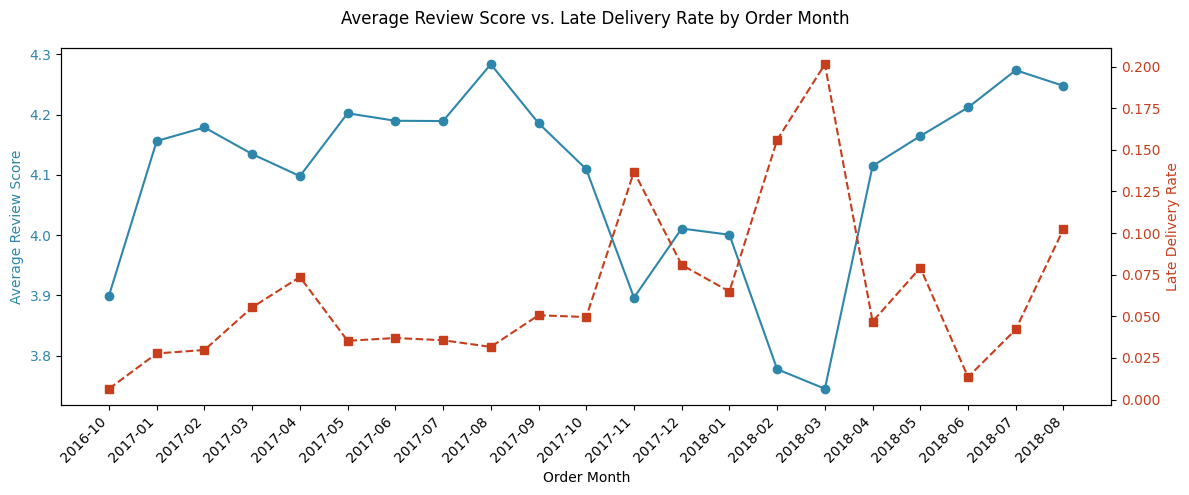

Correlation (monthly late rate vs. monthly avg review score): -0.71


In [ ]:
monthly = (
    delivered
    .assign(month=delivered['order_purchase_timestamp'].dt.to_period('M').astype(str))
    .groupby('month')
    .agg(avg_review=('review_score', 'mean'), late_rate=('is_late', 'mean'), n_orders=('review_score', 'size'))
    .reset_index()
)
monthly = monthly[monthly['n_orders'] > 100]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly['month'], monthly['avg_review'], color='#2E86AB', marker='o', label='Avg. Review Score')
ax1.set_ylabel('Average Review Score', color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.set_xlabel('Order Month')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['month'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['late_rate'], color='#C73E1D', marker='s', linestyle='--', label='Late Delivery Rate')
ax2.set_ylabel('Late Delivery Rate', color='#C73E1D')
ax2.tick_params(axis='y', labelcolor='#C73E1D')

fig.suptitle('Average Review Score vs. Late Delivery Rate by Order Month')
fig.tight_layout()
plt.show()

print(f"Correlation (monthly late rate vs. monthly avg review score): {monthly['avg_review'].corr(monthly['late_rate']):.2f}")

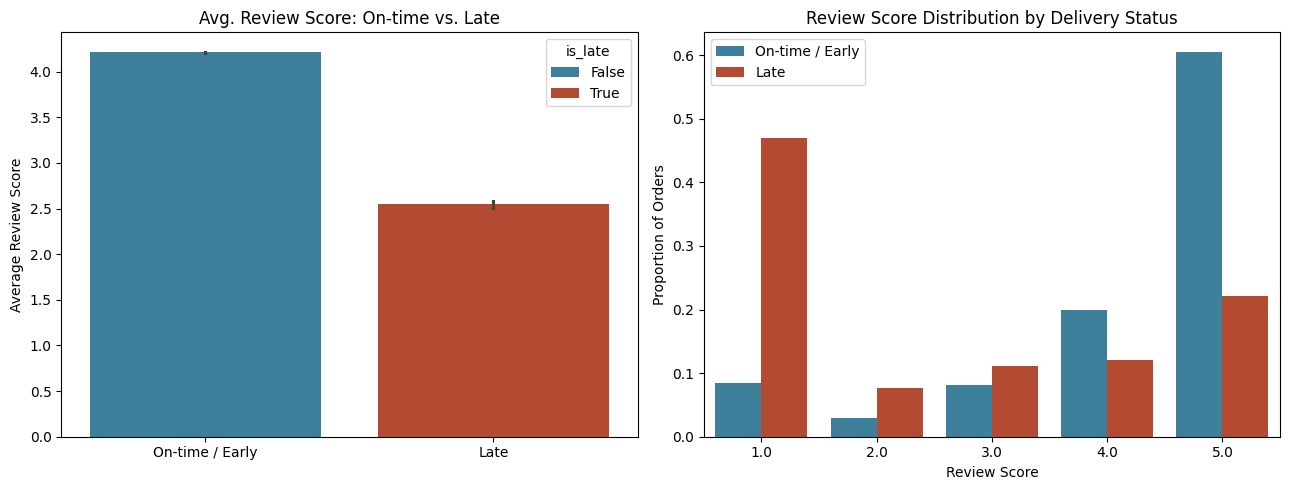

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=delivered, x='is_late', y='review_score', ax=axes[0], hue='is_late', palette=['#2E86AB', '#C73E1D'])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['On-time / Early', 'Late'])
axes[0].set_xlabel('')
axes[0].set_ylabel('Average Review Score')
axes[0].set_title('Avg. Review Score: On-time vs. Late')

score_dist = (
    delivered
    .groupby('is_late')['review_score']
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
)
score_dist['is_late'] = score_dist['is_late'].map({False: 'On-time / Early', True: 'Late'})

sns.barplot(data=score_dist, x='review_score', y='proportion', hue='is_late', ax=axes[1], palette=['#2E86AB', '#C73E1D'])
axes[1].set_title('Review Score Distribution by Delivery Status')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Proportion of Orders')
axes[1].legend(title='')

plt.tight_layout()
plt.show()

Although late deliveries make up a small fraction of Olist's completed orders, they are strongly and consistently associated with sharply lower review scores. This pattern holds across the whole dataset, not just in isolated months. These low reviews score doenst only translate to an operational conveniences, it actually describe a bad experience the customer had when using the service **Olist** offer. These bad experience could push a customer to try a competing marketplace instead, late delivery represents a concrete, measurable, and identifiable threat to customer retention.

## **1.3 Key Objectives**

This analysis is oriented around one central goal: **protecting customer satisfaction from the drop caused by late deliveries, before it turns into churn.** A customer who has one bad delivery experience and leaves a low review isn't just a lost review. They're a customer who may not come back to **Olist** the next time they need to buy something, and may go to a competitor instead.

Concretely, this means the analysis should:

- **Characterize where late deliveries come from**: which sellers, regions, shipping distances, or product categories show elevated late-delivery rates, so the problem can be localized rather than treated as random noise.
- **Quantify the satisfaction cost of lateness**: translating "late" into an expected drop in review score (and, by extension, into churn risk), so the business impact is measurable rather than anecdotal.
- **Surface early-warning signals**: identify which order characteristics are visible *before* or *shortly after* purchase (not just after the fact) that correlate with a late delivery, so Olist could realistically act on them rather than only explain them in hindsight.
- **Keep the analysis actionable for the business, not just descriptive**: findings should point toward levers **Olist** can actually pull (seller SLAs, carrier choice, buffer on estimated delivery dates, proactive customer communication on at-risk orders), since delivery delay is largely a supply-side problem the platform can influence.

## **1.4 Analytical Approach**

## **1.5 Metric Evaluation**

### **1.5.1 Business Cost of Misclassification**

### **1.5.2 Machine Learning Metrics & Business Alignment**

## **1.6 Success Criteria**